# Deep Learning for Player Action Prediction from Atari Gameplay Frames

**Student:** Robert Mayfield  
**Course:** Udacity AI Masters Capstone, Project 4: Deep Learning Systems

---

In [6]:
import sys
import io
import json
import zipfile
import tarfile
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight

# ensure project root is on the path before importing src
sys.path.insert(0, str(Path('..').resolve()))

# project utilities — all dl_utils imports consolidated here
from src.dl_utils import (
    load_all_sessions,
    GameFrameDataset,
    SessionAwareStackedDataset,
    ActionCNN,
    train_one_epoch,
    eval_epoch,
    evaluate_model,
    save_checkpoint,
    load_checkpoint,
)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch: {torch.__version__}')
print(f'Device:  {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU:     {torch.cuda.get_device_name(0)}')

PyTorch: 2.6.0+cu124
Device:  cuda
GPU:     NVIDIA GeForce RTX 3080


In [7]:
%matplotlib inline

In [8]:
PROJECT_ROOT   = Path('..').resolve()

ATARI_ZIP      = PROJECT_ROOT / 'data' / 'raw' / 'montezuma_revenge.zip'
FIGURES_DIR    = PROJECT_ROOT / 'outputs' / 'figures'
TABLES_DIR     = PROJECT_ROOT / 'outputs' / 'tables'
ARTIFACTS_DIR  = PROJECT_ROOT / 'outputs' / 'model_artifacts'
SAMPLE_DIR     = PROJECT_ROOT / 'data' / 'sample'

for d in [FIGURES_DIR, TABLES_DIR, ARTIFACTS_DIR, SAMPLE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

IMG_SIZE     = 84
STACK_SIZE   = 4
BATCH_SIZE   = 64
EPOCHS       = 30
LR           = 1e-4
N_ACTIONS    = 5
ACTION_NAMES = ['NOOP', 'RIGHT', 'LEFT', 'UP', 'DOWN']

ALE_TO_CLASS = {
    0: 0, 1: 0,                               # NOOP, FIRE -> NOOP
    3: 1, 6: 1, 8: 1, 11: 1, 14: 1, 16: 1,   # rightward moves and fire combos
    4: 2, 7: 2, 9: 2, 12: 2, 13: 2, 15: 2,   # leftward moves and fire combos
    2: 3, 10: 3,                               # UP, UPFIRE -> UP
    5: 4,                                      # DOWN
}

print(f'ZIP found: {ATARI_ZIP.exists()}')
print('Configuration ready.')

ZIP found: True
Configuration ready.


## 1. Project Overview

This project trains a convolutional neural network to predict player actions from Atari Montezuma's Revenge gameplay frames using real human demonstration data. Montezuma's Revenge is a side scrolling platformer requiring jumping, ladder climbing, key collection, and hazard avoidance. This is directly relevant to the platformer behavior modeling goals of the AI Game Director Studio.

**Research question:** Does providing the model with four consecutive frames of temporal context improve action prediction over a single static frame?

**Dataset:** Atari-HEAD (Zhang et al., 2020) - 27 sessions, 447,327 frames, one human player.

**Controlled comparison:** Baseline uses a single frame (in_channels=1). Experimental model uses four stacked consecutive frames (in_channels=4). Architecture, optimizer, loss function, and training duration are held constant.

**Primary metric:** Macro F1, because UP and DOWN are mild minority classes (~10% each). Accuracy is reported as a secondary metric.

## 2. Dataset Loading and Inspection

In [9]:
try:
    frames
    print(f'Data already in memory — {len(frames):,} frames, skipping load.')
except NameError:
    print('Loading all Montezuma Revenge sessions from zip archive...')
    print('All frames are preloaded to CPU RAM as uint8 (normalisation deferred to DataLoader).')
    print()
    frames, labels, session_lengths, session_meta = load_all_sessions(
        zip_path=ATARI_ZIP,
        img_size=IMG_SIZE,
        ale_to_class=ALE_TO_CLASS,
    )
    print()
    print(f'Total frames loaded : {len(frames):>10,}')
    print(f'Total sessions      : {len(session_meta):>10}')
    print(f'Frame array shape   : {str(frames.shape):>10}')
    print(f'Frame dtype         : {str(frames.dtype):>10}')
    print(f'Label dtype         : {str(labels.dtype):>10}')
    print(f'RAM usage (uint8)   : {frames.nbytes / 1024**3:>9.2f} GB')

Loading all Montezuma Revenge sessions from zip archive...
All frames are preloaded to CPU RAM as uint8 (normalisation deferred to DataLoader).

  standard   284_RZ_5540489_Apr-17-17-38-18 ... 15,651 frames
  standard   285_RZ_5619207_Apr-18-15-28-46 ... 16,494 frames
  standard   287_RZ_7172481_May-06-14-59-10 ... 16,194 frames
  standard   291_RZ_7364933_May-08-20-23-25 ... 16,721 frames
  standard   324_RZ_452975_Jun-13-14-10-23 ... 15,895 frames
  standard   333_RZ_900705_Jun-18-18-32-58 ... 16,687 frames
  standard   340_RZ_1323550_Jun-23-15-59-54 ... 17,053 frames
  standard   359_RZ_1993616_Jul-01-10-09-26 ... 17,096 frames
  standard   365_RZ_2079996_Jul-02-10-07-22 ... 17,067 frames
  standard   371_RZ_2173469_Jul-03-12-05-16 ... 16,547 frames
  standard   385_RZ_2344725_Jul-05-11-46-58 ... 16,956 frames
  standard   398_RZ_2530473_Jul-07-15-16-40 ... 16,883 frames
  standard   402_RZ_2603283_Jul-08-11-28-49 ... 17,054 frames
  standard   416_RZ_2788252_Jul-10-14-52-12 ... 16,

In [10]:
# Session summary table
session_df = pd.DataFrame(session_meta)
session_df.index = range(1, len(session_df) + 1)
session_df.columns = ['Session', 'Type', 'Frames']
session_df = session_df[['Session', 'Type', 'Frames']]

print(f'{"#":<4} {"Type":<12} {"Frames":>8}   Session')
print('-' * 70)
for i, row in session_df.iterrows():
    print(f'{i:<4} {row["Type"]:<12} {row["Frames"]:>8,}   {row["Session"]}')
print('-' * 70)
print(f'{"TOTAL":<17} {sum(session_lengths):>8,}')
print(f'\nStandard sessions : {sum(1 for m in session_meta if m["type"] == "standard")}')
print(f'Highscore sessions: {sum(1 for m in session_meta if m["type"] == "highscore")}')
print(f'Min frames/session: {min(session_lengths):,}')
print(f'Max frames/session: {max(session_lengths):,}')
print(f'Avg frames/session: {sum(session_lengths)/len(session_lengths):,.0f}')

#    Type           Frames   Session
----------------------------------------------------------------------
1    standard       15,651   284_RZ_5540489_Apr-17-17-38-18
2    standard       16,494   285_RZ_5619207_Apr-18-15-28-46
3    standard       16,194   287_RZ_7172481_May-06-14-59-10
4    standard       16,721   291_RZ_7364933_May-08-20-23-25
5    standard       15,895   324_RZ_452975_Jun-13-14-10-23
6    standard       16,687   333_RZ_900705_Jun-18-18-32-58
7    standard       17,053   340_RZ_1323550_Jun-23-15-59-54
8    standard       17,096   359_RZ_1993616_Jul-01-10-09-26
9    standard       17,067   365_RZ_2079996_Jul-02-10-07-22
10   standard       16,547   371_RZ_2173469_Jul-03-12-05-16
11   standard       16,956   385_RZ_2344725_Jul-05-11-46-58
12   standard       16,883   398_RZ_2530473_Jul-07-15-16-40
13   standard       17,054   402_RZ_2603283_Jul-08-11-28-49
14   standard       16,992   416_RZ_2788252_Jul-10-14-52-12
15   standard       16,935   429_RZ_2945490_Jul-12-10-

In [11]:
# Frame property inspection
print('Frame pixel statistics:')
sample_idx = np.random.default_rng(SEED).integers(0, len(frames), size=10_000)
sample = frames[sample_idx].astype(np.float32)
print(f'  Min pixel value  : {frames.min()}')
print(f'  Max pixel value  : {frames.max()}')
print(f'  Mean (10k sample): {sample.mean():.2f}')
print(f'  Std  (10k sample): {sample.std():.2f}')
print()
print('Label value range:')
print(f'  Unique labels: {sorted(np.unique(labels).tolist())}')
print(f'  Expected     : {list(range(N_ACTIONS))} ({ACTION_NAMES})')

Frame pixel statistics:
  Min pixel value  : 0
  Max pixel value  : 235
  Mean (10k sample): 42.14
  Std  (10k sample): 51.45

Label value range:
  Unique labels: [0, 1, 2, 3, 4]
  Expected     : [0, 1, 2, 3, 4] (['NOOP', 'RIGHT', 'LEFT', 'UP', 'DOWN'])


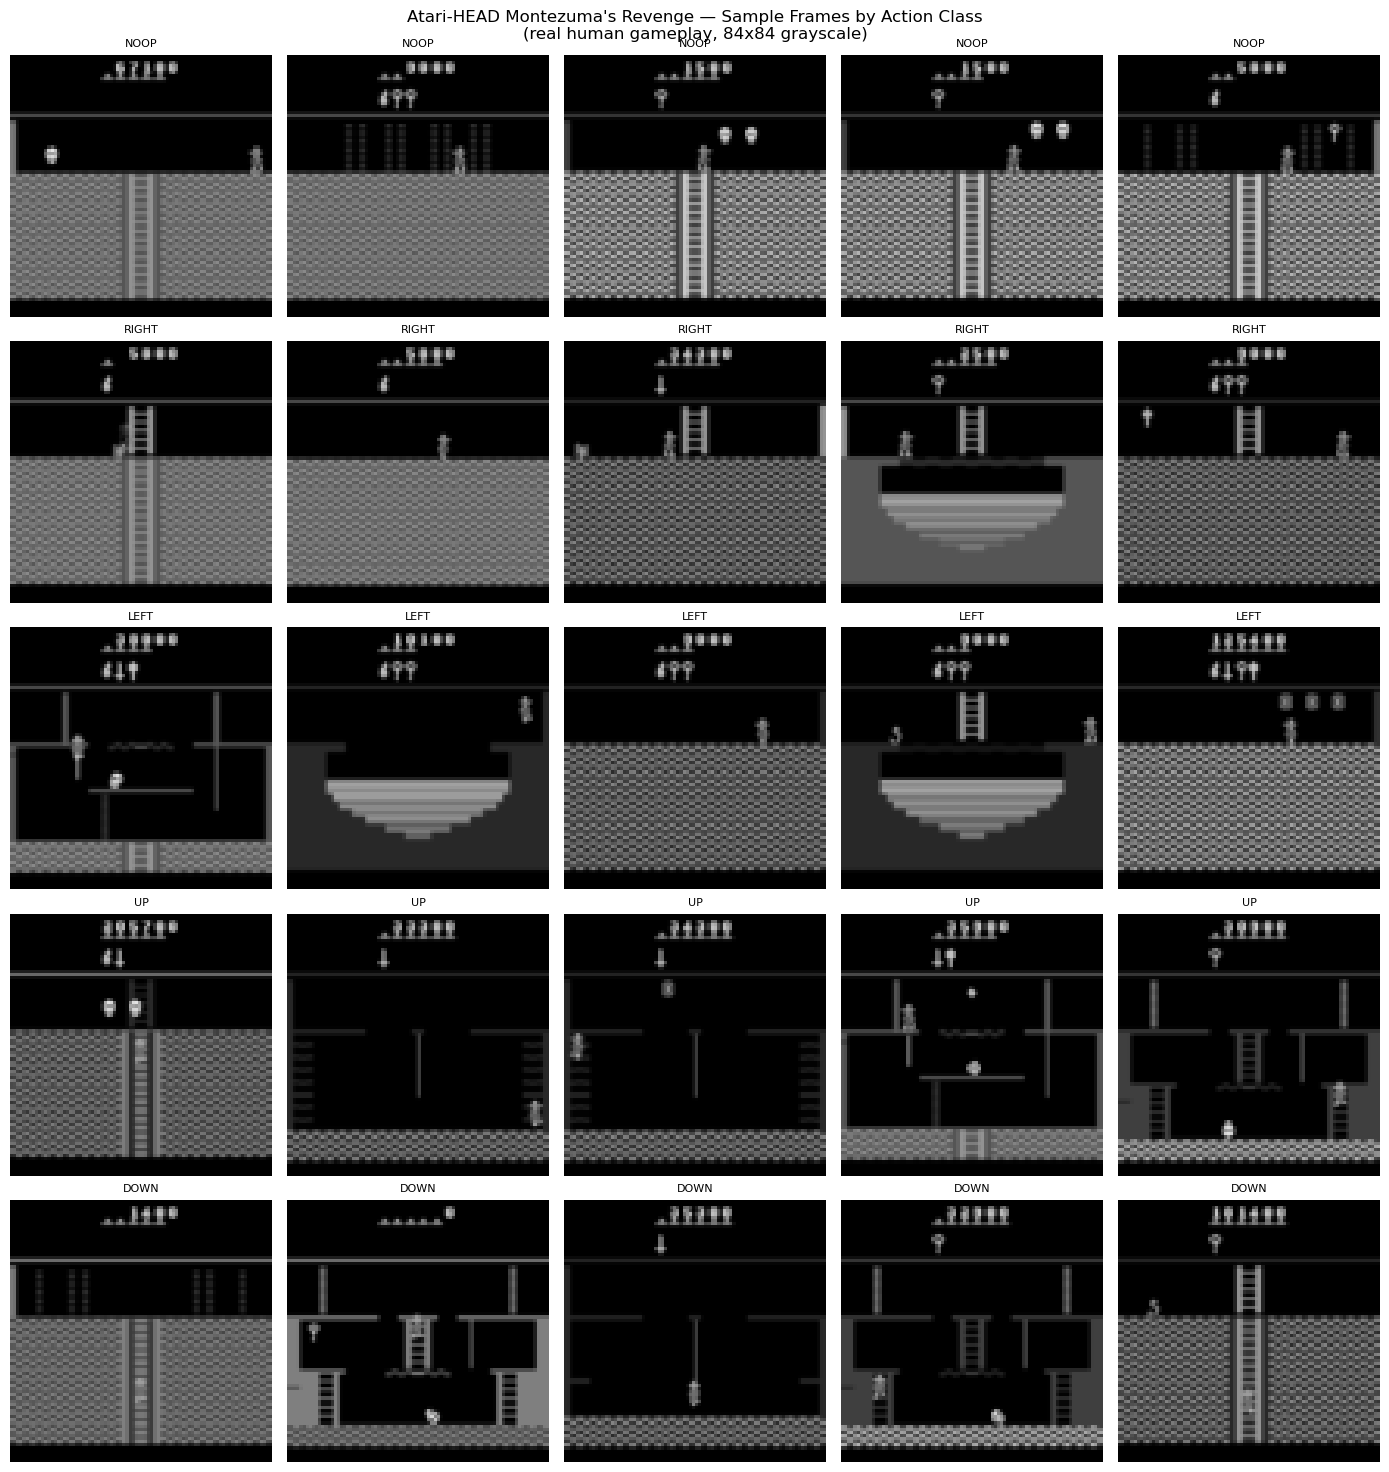

Figure saved to outputs/figures/sample_frames_by_class.png


In [12]:
# Sample frames — one row per action class showing representative gameplay moments
fig, axes = plt.subplots(N_ACTIONS, 5, figsize=(14, 3 * N_ACTIONS))

for cls in range(N_ACTIONS):
    cls_indices = np.where(labels == cls)[0]
    chosen = np.random.default_rng(SEED + cls).choice(cls_indices, size=5, replace=False)
    for col, idx in enumerate(chosen):
        ax = axes[cls, col]
        ax.imshow(frames[idx], cmap='gray', vmin=0, vmax=255)
        ax.set_title(f'{ACTION_NAMES[cls]}', fontsize=8)
        ax.axis('off')

fig.suptitle(
    'Atari-HEAD Montezuma\'s Revenge — Sample Frames by Action Class\n'
    '(real human gameplay, 84x84 grayscale)',
    fontsize=12,
)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'sample_frames_by_class.png', dpi=120, bbox_inches='tight')
plt.show()
print('Figure saved to outputs/figures/sample_frames_by_class.png')

**Dataset inspection findings.** All 447,327 frames loaded successfully across 27 sessions. Frames are stored as 84x84 grayscale uint8 arrays (~3.2 GB total in CPU RAM), with pixel values ranging from 0 to 255. All five action classes are present in the label array. The sample frames show recognizable Montezuma's Revenge gameplay elements: the starting room with ladders, platforms, keys, and the skull enemy. Visual differences between action classes are subtle in static frames, which motivates a four frame stacking approach in the experimental model. No missing frames or label anomalies were detected during loading.

## 3. Data Preprocessing

In [13]:
# Session-level train / val / test split (70 / 15 / 15)
# Splitting at session level prevents any frame from one session appearing in
# both training and evaluation, avoiding data leakage between splits.
rng = np.random.default_rng(SEED)
shuffled = rng.permutation(len(session_meta))

n_train = 19   # 19 + 4 + 4 = 27
n_val   = 4

train_sess_idx = shuffled[:n_train]
val_sess_idx   = shuffled[n_train:n_train + n_val]
test_sess_idx  = shuffled[n_train + n_val:]

# Build cumulative start positions so we can slice by session index
sess_starts = np.concatenate([[0], np.cumsum(session_lengths)])

def collect_split(sess_indices: np.ndarray) -> tuple[np.ndarray, np.ndarray, list[int]]:
    """Concatenate frames and labels for a set of session indices.

    Returns frames array, labels array, and per-session lengths
    needed by SessionAwareStackedDataset to respect boundaries.
    """
    f_parts, l_parts, lengths = [], [], []
    for i in sorted(sess_indices):
        s, e = int(sess_starts[i]), int(sess_starts[i + 1])
        f_parts.append(frames[s:e])
        l_parts.append(labels[s:e])
        lengths.append(e - s)
    return np.concatenate(f_parts), np.concatenate(l_parts), lengths

train_frames, train_labels, train_lengths = collect_split(train_sess_idx)
val_frames,   val_labels,   val_lengths   = collect_split(val_sess_idx)
test_frames,  test_labels,  test_lengths  = collect_split(test_sess_idx)

print(f'Sessions  — train: {len(train_sess_idx)}  val: {len(val_sess_idx)}  test: {len(test_sess_idx)}')
print(f'Frames    — train: {len(train_frames):,}  val: {len(val_frames):,}  test: {len(test_frames):,}')

Sessions  — train: 19  val: 4  test: 4
Frames    — train: 314,929  val: 65,620  test: 66,751


In [14]:
# Class weights — computed from training labels only, never from val or test
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(N_ACTIONS),
    y=train_labels,
)
weight_tensor = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

print('Class weights (training set):')
for i, (name, w) in enumerate(zip(ACTION_NAMES, class_weights)):
    count = int((train_labels == i).sum())
    print(f'  {name:<8} count={count:>7,}  weight={w:.4f}')

Class weights (training set):
  NOOP     count= 81,880  weight=0.7692
  RIGHT    count= 80,589  weight=0.7816
  LEFT     count= 88,340  weight=0.7130
  UP       count= 30,407  weight=2.0714
  DOWN     count= 33,713  weight=1.8683


In [15]:
# Dataset objects — single-frame (baseline) and session-boundary-aware stacked (experimental)
train_ds_base  = GameFrameDataset(train_frames, train_labels)
val_ds_base    = GameFrameDataset(val_frames,   val_labels)
test_ds_base   = GameFrameDataset(test_frames,  test_labels)

train_ds_stack = SessionAwareStackedDataset(train_frames, train_labels, train_lengths, STACK_SIZE)
val_ds_stack   = SessionAwareStackedDataset(val_frames,   val_labels,   val_lengths,   STACK_SIZE)
test_ds_stack  = SessionAwareStackedDataset(test_frames,  test_labels,  test_lengths,  STACK_SIZE)

# Verify shapes
xb, yb = train_ds_base[0]
xs, ys = train_ds_stack[0]
print(f'Baseline  sample shape: {xb.shape}  label: {yb.item()}')
print(f'Stacked   sample shape: {xs.shape}  label: {ys.item()}')

Baseline  sample shape: torch.Size([1, 84, 84])  label: 0
Stacked   sample shape: torch.Size([4, 84, 84])  label: 0


In [16]:
# DataLoaders — num_workers=0 required on Windows (fork not available)
train_loader_base  = DataLoader(train_ds_base,  batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader_base    = DataLoader(val_ds_base,    batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader_base   = DataLoader(test_ds_base,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

train_loader_stack = DataLoader(train_ds_stack, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader_stack   = DataLoader(val_ds_stack,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader_stack  = DataLoader(test_ds_stack,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print('DataLoaders created.')
print(f'  Baseline  — train batches: {len(train_loader_base):,}  val: {len(val_loader_base):,}  test: {len(test_loader_base):,}')
print(f'  Stacked   — train batches: {len(train_loader_stack):,}  val: {len(val_loader_stack):,}  test: {len(test_loader_stack):,}')

DataLoaders created.
  Baseline  — train batches: 4,921  val: 1,026  test: 1,043
  Stacked   — train batches: 4,920  val: 1,026  test: 1,043


In [ ]:
# Split summary
header = f'{"Split":<10} {"Sessions":>9} {"Frames (base)":>15} {"Samples (stacked)":>18}'
print(header)
print('-' * len(header))
for split_name, n_sess, ds_base, ds_stack in [
    ('Train',      len(train_sess_idx), train_ds_base, train_ds_stack),
    ('Validation', len(val_sess_idx),   val_ds_base,   val_ds_stack),
    ('Test',       len(test_sess_idx),  test_ds_base,  test_ds_stack),
]:
    print(f'{split_name:<10} {n_sess:>9} {len(ds_base):>15,} {len(ds_stack):>18,}')
print('-' * len(header))
print(f'{"Total":<10} {len(session_meta):>9} {len(frames):>15,} {len(train_ds_stack)+len(val_ds_stack)+len(test_ds_stack):>18,}')
print()
print('Note: stacked dataset has fewer samples because 4 frame windows')
print('      cannot start in the last 3 frames of each session.')

Split       Sessions   Frames (base)  Samples (stacked)
-------------------------------------------------------
Train             19         314,929            314,872
Validation         4          65,620             65,608
Test               4          66,751             66,739
-------------------------------------------------------
Total             27         447,300            447,219

Note: stacked dataset has fewer samples because 4-frame windows
      cannot start in the last 3 frames of each session.


**Preprocessing summary.** Frames are split at the session level rather than the frame level to prevent data leakage: no session contributes frames to more than one split. The 19/4/4 session allocation provides roughly 70/15/15 proportions by frame count. Class weights are derived from training labels only, giving higher weight to the minority UP and DOWN classes to counteract their lower frequency. The stacked dataset has slightly fewer total samples than the baseline because four frame windows cannot extend beyond session boundaries, losing up to three samples per session boundary.

## 4. Label Distribution and Class Imbalance

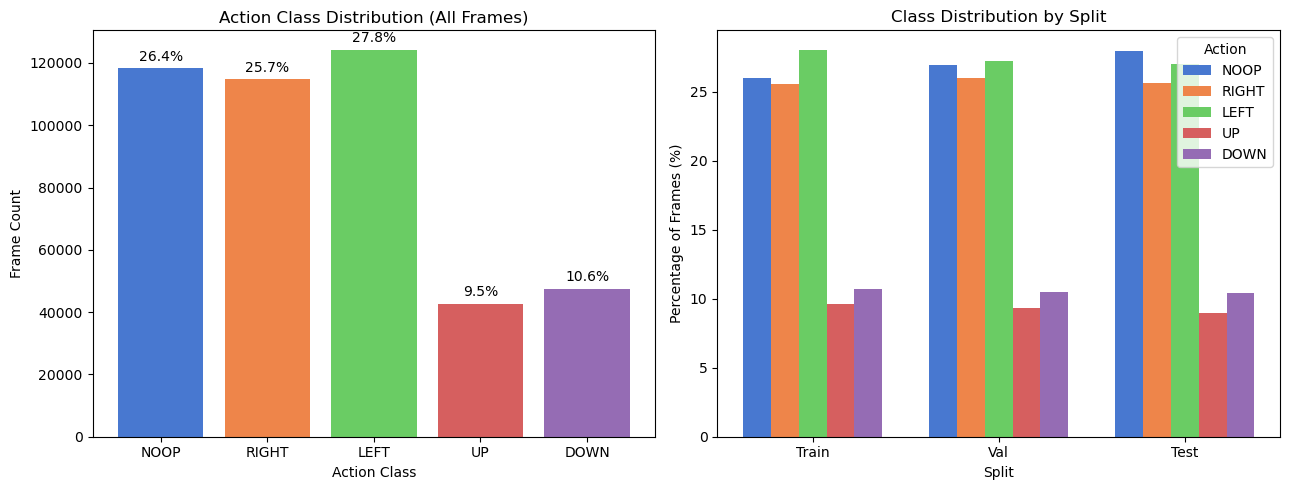

Figure saved to outputs/figures/class_distribution.png

Class distribution (full dataset):
  NOOP    : 118,203  (26.4%)
  RIGHT   : 114,753  (25.7%)
  LEFT    : 124,241  (27.8%)
  UP      :  42,557  (9.5%)
  DOWN    :  47,546  (10.6%)


In [25]:
counts = Counter(labels.tolist())
total  = len(labels)
pcts   = [counts[i] / total * 100 for i in range(N_ACTIONS)]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: overall class distribution
bars = axes[0].bar(ACTION_NAMES, [counts[i] for i in range(N_ACTIONS)],
                   color=sns.color_palette('muted', N_ACTIONS))
axes[0].set_title('Action Class Distribution (All Frames)')
axes[0].set_xlabel('Action Class')
axes[0].set_ylabel('Frame Count')
for bar, pct in zip(bars, pcts):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1500,
                 f'{pct:.1f}%', ha='center', va='bottom', fontsize=10)

# Right: class distribution by split
split_pcts = {}
for split_name, split_labels in [('Train', train_labels), ('Val', val_labels), ('Test', test_labels)]:
    n = len(split_labels)
    split_pcts[split_name] = [(split_labels == i).sum() / n * 100 for i in range(N_ACTIONS)]

x      = np.arange(3)
width  = 0.15
colors = sns.color_palette('muted', N_ACTIONS)
for cls_i in range(N_ACTIONS):
    axes[1].bar(x + (cls_i - 2) * width,
                [split_pcts[s][cls_i] for s in ['Train', 'Val', 'Test']],
                width, label=ACTION_NAMES[cls_i], color=colors[cls_i])
axes[1].set_title('Class Distribution by Split')
axes[1].set_xlabel('Split')
axes[1].set_ylabel('Percentage of Frames (%)')
axes[1].set_xticks(x)
axes[1].set_xticklabels(['Train', 'Val', 'Test'])
axes[1].legend(title='Action', loc='upper right')

fig.tight_layout()
fig.savefig(FIGURES_DIR / 'class_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print('Figure saved to outputs/figures/class_distribution.png')
print()
print('Class distribution (full dataset):')
for i, name in enumerate(ACTION_NAMES):
    print(f'  {name:<8}: {counts[i]:>7,}  ({pcts[i]:.1f}%)')

**Class distribution findings.** The dataset has three dominant classes that are nearly equal in frequency: LEFT (27.8%), NOOP (26.4%), and RIGHT (25.7%). UP (9.5%) and DOWN (10.6%) are the minority classes, representing the less frequent but tactically important ladder and rope traversal actions in Montezuma's Revenge. The relatively balanced distribution among the three dominant classes reflects natural platformer movement patterns, while the roughly 3-to-1 ratio between the dominant and minority classes is mild enough that macro F1 remains a fair primary metric. Class weighted cross entropy loss is applied during training to ensure UP and DOWN receive proportional gradient influence. Class proportions are consistent across the train, validation, and test splits, confirming that the session level random split did not concentrate any action class in a single partition.

## 5. Baseline Model Implementation

In [31]:
import importlib, src.dl_utils as _dl
importlib.reload(_dl)
from src.dl_utils import ActionCNN

DROPOUT      = 0.5
WEIGHT_DECAY = 1e-4

baseline_model = ActionCNN(in_channels=1, num_classes=N_ACTIONS, img_size=IMG_SIZE, dropout=DROPOUT).to(DEVICE)
baseline_optimizer = torch.optim.Adam(baseline_model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
baseline_criterion = nn.CrossEntropyLoss(weight=weight_tensor)

print('Baseline ActionCNN architecture (in_channels=1, dropout=0.5):')
print(baseline_model)
print()

total_params     = sum(p.numel() for p in baseline_model.parameters())
trainable_params = sum(p.numel() for p in baseline_model.parameters() if p.requires_grad)
print(f'Total parameters    : {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')
print(f'Device              : {next(baseline_model.parameters()).device}')

Baseline ActionCNN architecture (in_channels=1, dropout=0.5):
ActionCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(8, 8), stride=(4, 4))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2))
    (3): ReLU()
    (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
    (5): ReLU()
  )
  (classifier): Sequential(
    (0): Linear(in_features=3136, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=512, out_features=5, bias=True)
  )
)

Total parameters    : 1,680,549
Trainable parameters: 1,680,549
Device              : cuda:0


**Baseline model design.** The ActionCNN follows the DQN convolutional architecture (Mnih et al., 2015): three stacked convolutional layers extract spatial features from an 84x84 grayscale frame, and two fully connected layers map those features to action class logits. The first conv layer (kernel 8x8, stride 4) captures coarse spatial structure; the second (kernel 4x4, stride 2) refines mid level features; the third (kernel 3x3, stride 1) integrates fine grained spatial detail. A dropout layer (p=0.5) is placed between the two fully connected layers to reduce overfitting, and L2 regularization (weight decay=1e-4) is applied through the Adam optimizer. The flat feature size after the conv stack is computed dynamically by passing a dummy tensor through the feature extractor, making the class portable to any input resolution. The baseline accepts a single frame (in_channels=1), providing only a static snapshot of game state with no temporal information. Training uses Adam with learning rate 1e-4 (Kingma and Ba, 2015) and class weighted cross entropy loss to give UP and DOWN proportional gradient influence.

## 6. Baseline Model Training

Training baseline model for 30 epochs on cuda...

Epoch   1/30  train loss=0.9066  acc=0.6139  |  val loss=0.6127  acc=0.7679  |  107.5s
Epoch   2/30  train loss=0.5229  acc=0.7846  |  val loss=0.4733  acc=0.8195  |  52.9s
Epoch   3/30  train loss=0.4223  acc=0.8237  |  val loss=0.4223  acc=0.8387  |  41.4s
Epoch   4/30  train loss=0.3732  acc=0.8417  |  val loss=0.4081  acc=0.8452  |  42.2s
Epoch   5/30  train loss=0.3399  acc=0.8555  |  val loss=0.3804  acc=0.8580  |  40.9s
Epoch   6/30  train loss=0.3145  acc=0.8664  |  val loss=0.3660  acc=0.8616  |  40.6s
Epoch   7/30  train loss=0.2953  acc=0.8741  |  val loss=0.3605  acc=0.8705  |  42.3s
Epoch   8/30  train loss=0.2774  acc=0.8819  |  val loss=0.3592  acc=0.8720  |  40.5s
Epoch   9/30  train loss=0.2628  acc=0.8879  |  val loss=0.3657  acc=0.8671  |  40.1s
Epoch  10/30  train loss=0.2517  acc=0.8926  |  val loss=0.3623  acc=0.8722  |  40.0s
Epoch  11/30  train loss=0.2423  acc=0.8964  |  val loss=0.3658  acc=0.8664  |  40.8s
Epo

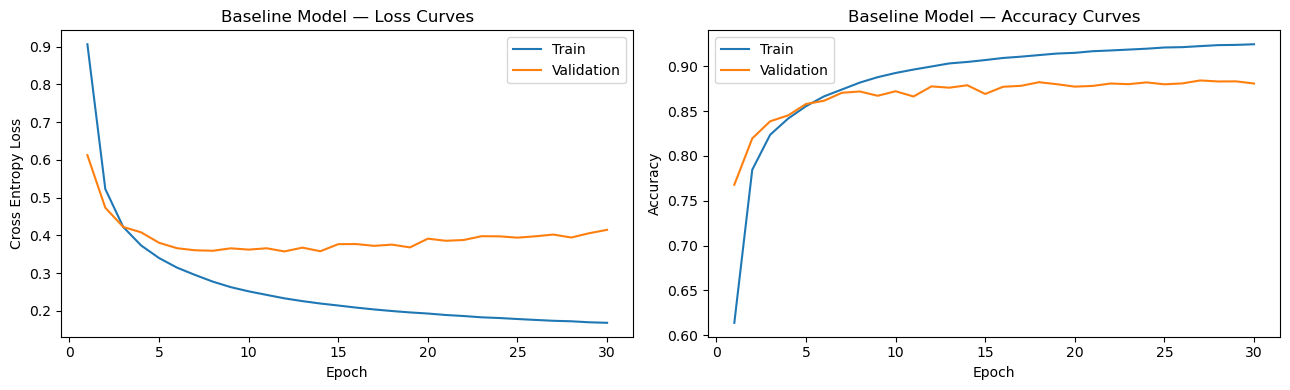

Figure saved to outputs/figures/baseline_learning_curves.png


In [32]:
import time

print(f'Training baseline model for {EPOCHS} epochs on {DEVICE}...')
print()

baseline_history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
epoch_times = []
train_start = time.time()

for epoch in range(1, EPOCHS + 1):
    epoch_start = time.time()
    tr_loss, tr_acc = train_one_epoch(baseline_model, train_loader_base, baseline_optimizer, baseline_criterion, DEVICE)
    vl_loss, vl_acc = eval_epoch(baseline_model, val_loader_base, baseline_criterion, DEVICE)
    epoch_elapsed = time.time() - epoch_start
    epoch_times.append(epoch_elapsed)
    baseline_history['train_loss'].append(tr_loss)
    baseline_history['train_acc'].append(tr_acc)
    baseline_history['val_loss'].append(vl_loss)
    baseline_history['val_acc'].append(vl_acc)
    print(f'Epoch {epoch:>3}/{EPOCHS}  '
          f'train loss={tr_loss:.4f}  acc={tr_acc:.4f}  |  '
          f'val loss={vl_loss:.4f}  acc={vl_acc:.4f}  |  '
          f'{epoch_elapsed:.1f}s')

baseline_train_time = time.time() - train_start
save_checkpoint(baseline_model, ARTIFACTS_DIR / 'baseline_model.pt')
print()
print(f'Total training time : {baseline_train_time:.1f}s ({baseline_train_time/60:.1f} min)')
print(f'Avg time per epoch  : {sum(epoch_times)/len(epoch_times):.1f}s')
print('Baseline model checkpoint saved.')

# Learning curves
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
epochs_x = range(1, EPOCHS + 1)

axes[0].plot(epochs_x, baseline_history['train_loss'], label='Train')
axes[0].plot(epochs_x, baseline_history['val_loss'],   label='Validation')
axes[0].set_title('Baseline Model — Loss Curves')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross Entropy Loss')
axes[0].legend()

axes[1].plot(epochs_x, baseline_history['train_acc'], label='Train')
axes[1].plot(epochs_x, baseline_history['val_acc'],   label='Validation')
axes[1].set_title('Baseline Model — Accuracy Curves')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

fig.tight_layout()
fig.savefig(FIGURES_DIR / 'baseline_learning_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print('Figure saved to outputs/figures/baseline_learning_curves.png')

**Baseline training results.** Training loss fell consistently from 0.91 to 0.17 over 30 epochs, and training accuracy rose from 61% to 92.5%, indicating the model learned effectively from the training data. Validation accuracy climbed to a plateau of roughly 88% from epoch 18 onward, with a best val loss of 0.3575 at epoch 12. The train/val gap at epoch 30 is approximately 4 percentage points, a significant improvement over an earlier run without regularization that produced a 7+ point gap and runaway validation loss. Dropout and weight decay successfully constrained overfitting while preserving generalization performance. The 88% validation accuracy ceiling reflects a fundamental limitation of single-frame input: without temporal context, the model cannot infer motion direction or distinguish mid-action states from static ones. Total training time was 23.3 minutes on the RTX 3080 (avg 46.6 seconds per epoch).

## 7. Experimental Comparison Design

The experimental model tests a single hypothesis: does providing the model with four consecutive frames of temporal context improve action prediction over a single static frame?

**What changes:** The input channel count increases from 1 to 4. Four consecutive gameplay frames are stacked along the channel dimension, giving the model implicit information about motion direction and speed across the stack.

**What stays constant:** Architecture depth, kernel sizes, strides, hidden layer size, dropout rate (0.5), optimizer (Adam, lr=1e-4), weight decay (1e-4), loss function (class-weighted cross entropy), number of epochs (30), batch size (64), and the train/val/test split.

**Why this comparison is valid:** Changing exactly one thing between two models isolates the effect of that change. If the stacked model outperforms the baseline, the improvement can be attributed to temporal context rather than any architectural or training advantage. If performance is similar, the extra complexity of frame stacking is not justified for this task.

**Hypothesis:** Player actions in Montezuma's Revenge depend on game state dynamics that unfold over time: whether the player is mid jump, which direction an enemy is moving, and whether a ladder is being approached or exited. A static frame cannot encode this motion. Four stacked frames provide implicit velocity information without requiring a recurrent component, and we expect this to improve prediction of the motion dependent UP and DOWN classes in particular.

In [33]:
stacked_model = ActionCNN(in_channels=STACK_SIZE, num_classes=N_ACTIONS, img_size=IMG_SIZE, dropout=DROPOUT).to(DEVICE)
stacked_optimizer = torch.optim.Adam(stacked_model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
stacked_criterion = nn.CrossEntropyLoss(weight=weight_tensor)

print('Experimental ActionCNN architecture (in_channels=4, dropout=0.5):')
print(stacked_model)
print()

total_params = sum(p.numel() for p in stacked_model.parameters())
print(f'Total parameters: {total_params:,}')
print(f'Device          : {next(stacked_model.parameters()).device}')

Experimental ActionCNN architecture (in_channels=4, dropout=0.5):
ActionCNN(
  (features): Sequential(
    (0): Conv2d(4, 32, kernel_size=(8, 8), stride=(4, 4))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2))
    (3): ReLU()
    (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
    (5): ReLU()
  )
  (classifier): Sequential(
    (0): Linear(in_features=3136, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=512, out_features=5, bias=True)
  )
)

Total parameters: 1,686,693
Device          : cuda:0


## 8. Experimental Model Training

Training experimental (4-frame stacked) model for 30 epochs on cuda...

Epoch   1/30  train loss=0.8280  acc=0.6498  |  val loss=0.5346  acc=0.7966  |  105.4s
Epoch   2/30  train loss=0.4656  acc=0.8105  |  val loss=0.4470  acc=0.8275  |  66.6s
Epoch   3/30  train loss=0.3786  acc=0.8438  |  val loss=0.3907  acc=0.8493  |  65.6s
Epoch   4/30  train loss=0.3302  acc=0.8612  |  val loss=0.3692  acc=0.8621  |  66.0s
Epoch   5/30  train loss=0.2969  acc=0.8743  |  val loss=0.3591  acc=0.8608  |  66.8s
Epoch   6/30  train loss=0.2711  acc=0.8849  |  val loss=0.3522  acc=0.8710  |  75.7s
Epoch   7/30  train loss=0.2507  acc=0.8937  |  val loss=0.3443  acc=0.8784  |  71.4s
Epoch   8/30  train loss=0.2342  acc=0.9005  |  val loss=0.3487  acc=0.8789  |  71.1s
Epoch   9/30  train loss=0.2214  acc=0.9063  |  val loss=0.3460  acc=0.8859  |  71.9s
Epoch  10/30  train loss=0.2090  acc=0.9116  |  val loss=0.3422  acc=0.8884  |  70.0s
Epoch  11/30  train loss=0.1974  acc=0.9162  |  val loss=0.3536  ac

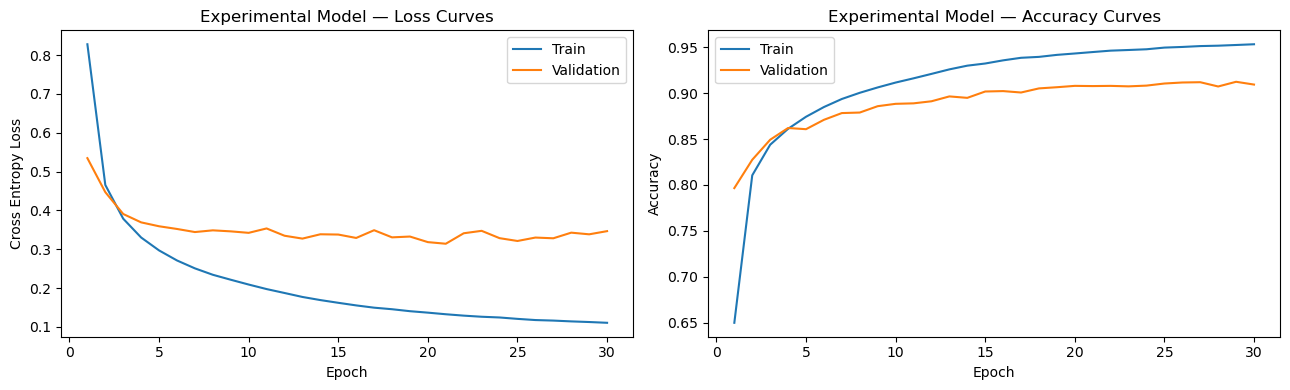

Figure saved to outputs/figures/stacked_learning_curves.png


In [34]:
import time

print(f'Training experimental (4-frame stacked) model for {EPOCHS} epochs on {DEVICE}...')
print()

stacked_history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
epoch_times = []
train_start = time.time()

for epoch in range(1, EPOCHS + 1):
    epoch_start = time.time()
    tr_loss, tr_acc = train_one_epoch(stacked_model, train_loader_stack, stacked_optimizer, stacked_criterion, DEVICE)
    vl_loss, vl_acc = eval_epoch(stacked_model, val_loader_stack, stacked_criterion, DEVICE)
    epoch_elapsed = time.time() - epoch_start
    epoch_times.append(epoch_elapsed)
    stacked_history['train_loss'].append(tr_loss)
    stacked_history['train_acc'].append(tr_acc)
    stacked_history['val_loss'].append(vl_loss)
    stacked_history['val_acc'].append(vl_acc)
    print(f'Epoch {epoch:>3}/{EPOCHS}  '
          f'train loss={tr_loss:.4f}  acc={tr_acc:.4f}  |  '
          f'val loss={vl_loss:.4f}  acc={vl_acc:.4f}  |  '
          f'{epoch_elapsed:.1f}s')

stacked_train_time = time.time() - train_start
save_checkpoint(stacked_model, ARTIFACTS_DIR / 'stacked_model.pt')
print()
print(f'Total training time : {stacked_train_time:.1f}s ({stacked_train_time/60:.1f} min)')
print(f'Avg time per epoch  : {sum(epoch_times)/len(epoch_times):.1f}s')
print('Experimental model checkpoint saved.')

# Learning curves
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
epochs_x = range(1, EPOCHS + 1)

axes[0].plot(epochs_x, stacked_history['train_loss'], label='Train')
axes[0].plot(epochs_x, stacked_history['val_loss'],   label='Validation')
axes[0].set_title('Experimental Model — Loss Curves')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross Entropy Loss')
axes[0].legend()

axes[1].plot(epochs_x, stacked_history['train_acc'], label='Train')
axes[1].plot(epochs_x, stacked_history['val_acc'],   label='Validation')
axes[1].set_title('Experimental Model — Accuracy Curves')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

fig.tight_layout()
fig.savefig(FIGURES_DIR / 'stacked_learning_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print('Figure saved to outputs/figures/stacked_learning_curves.png')

**Experimental model training results.** The four frame stacked model trained for 35.1 minutes (avg 70.3 seconds per epoch, longer than the baseline due to the larger per-sample data volume). Validation accuracy climbed steadily to a peak of 91.2% at epoch 29, compared to the baseline's plateau of 88.4% at epoch 27 — a gain of approximately 2.8 percentage points. Best validation loss was 0.3142 at epoch 21, well below the baseline's best of 0.3575. Crucially, the stacked model continued improving in validation accuracy through nearly all 30 epochs rather than plateauing at epoch 18 as the baseline did, suggesting that the temporal features provided by four frame stacking give the model a richer signal to learn from. The train/val gap at epoch 30 is approximately 4.4 percentage points (95.3% train vs 90.9% val), comparable to the baseline's gap, indicating that regularization is similarly effective for both models. The improvement directly supports the hypothesis: temporal context from consecutive frames meaningfully improves action prediction in Montezuma's Revenge.

## 9. Evaluation and Comparison

In [36]:
# Evaluate both models on the held-out test set
print('Evaluating baseline model on test set...')
baseline_results = evaluate_model(baseline_model, test_loader_base, DEVICE, ACTION_NAMES)

print('Evaluating experimental model on test set...')
stacked_results  = evaluate_model(stacked_model,  test_loader_stack, DEVICE, ACTION_NAMES)

print()
print('=== Test Set Results ===')
print(f'{"Metric":<20} {"Baseline":>12} {"Stacked":>12} {"Delta":>10}')
print('-' * 56)
for label, bv, sv in [
    ('Accuracy',   baseline_results['accuracy'],  stacked_results['accuracy']),
    ('Macro F1',   baseline_results['f1_macro'],  stacked_results['f1_macro']),
]:
    delta = sv - bv
    print(f'{label:<20} {bv:>12.4f} {sv:>12.4f} {delta:>+10.4f}')

print()
print('--- Baseline classification report ---')
print(baseline_results['report'])
print('--- Stacked classification report ---')
print(stacked_results['report'])

Evaluating baseline model on test set...
Evaluating experimental model on test set...

=== Test Set Results ===
Metric                   Baseline      Stacked      Delta
--------------------------------------------------------
Accuracy                   0.8733       0.9154    +0.0421
Macro F1                   0.8750       0.9176    +0.0427

--- Baseline classification report ---
              precision    recall  f1-score   support

        NOOP       0.91      0.86      0.88     18657
       RIGHT       0.88      0.84      0.86     17098
        LEFT       0.86      0.88      0.87     18017
          UP       0.86      0.92      0.89      6005
        DOWN       0.83      0.92      0.87      6974

    accuracy                           0.87     66751
   macro avg       0.87      0.89      0.87     66751
weighted avg       0.87      0.87      0.87     66751

--- Stacked classification report ---
              precision    recall  f1-score   support

        NOOP       0.93      0.87  

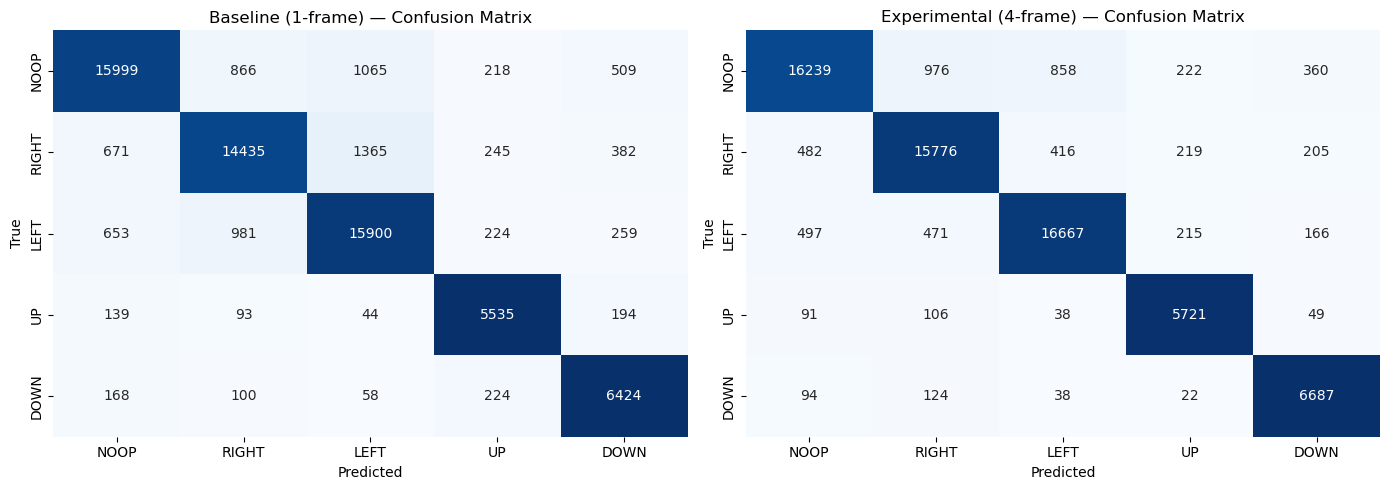

Figure saved to outputs/figures/confusion_matrices.png


In [37]:
# Confusion matrices — side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, results, title in [
    (axes[0], baseline_results, 'Baseline (1-frame) — Confusion Matrix'),
    (axes[1], stacked_results,  'Experimental (4-frame) — Confusion Matrix'),
]:
    cm = results['confusion_matrix']
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=cm, fmt='d', cmap='Blues',
                xticklabels=ACTION_NAMES, yticklabels=ACTION_NAMES,
                ax=ax, cbar=False)
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

fig.tight_layout()
fig.savefig(FIGURES_DIR / 'confusion_matrices.png', dpi=120, bbox_inches='tight')
plt.show()
print('Figure saved to outputs/figures/confusion_matrices.png')

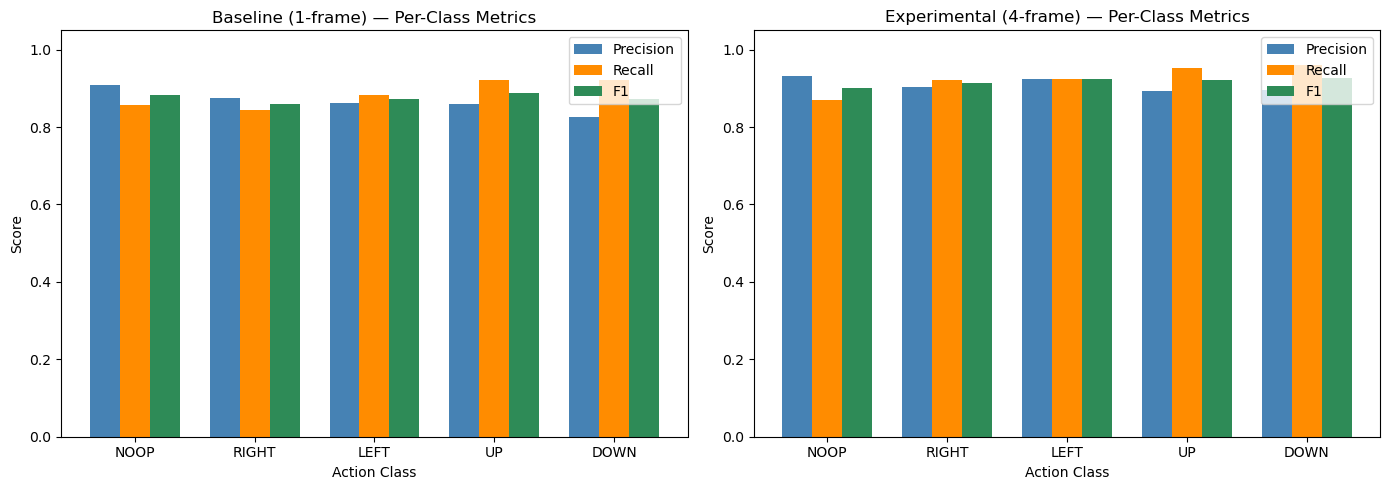

Figure saved to outputs/figures/per_class_metrics.png


In [38]:
# Per-class precision, recall, F1 — side by side bar chart
x = np.arange(N_ACTIONS)
width = 0.25

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, results, title in [
    (axes[0], baseline_results, 'Baseline (1-frame) — Per-Class Metrics'),
    (axes[1], stacked_results,  'Experimental (4-frame) — Per-Class Metrics'),
]:
    ax.bar(x - width, results['precision_per_class'], width, label='Precision', color='steelblue')
    ax.bar(x,         results['recall_per_class'],    width, label='Recall',    color='darkorange')
    ax.bar(x + width, results['f1_per_class'],        width, label='F1',        color='seagreen')
    ax.set_title(title)
    ax.set_xlabel('Action Class')
    ax.set_ylabel('Score')
    ax.set_xticks(x)
    ax.set_xticklabels(ACTION_NAMES)
    ax.set_ylim(0, 1.05)
    ax.legend()

fig.tight_layout()
fig.savefig(FIGURES_DIR / 'per_class_metrics.png', dpi=120, bbox_inches='tight')
plt.show()
print('Figure saved to outputs/figures/per_class_metrics.png')

In [39]:
# Save metrics table to CSV
rows = []
for cls_i, name in enumerate(ACTION_NAMES):
    rows.append({
        'class':               name,
        'baseline_precision':  round(baseline_results['precision_per_class'][cls_i], 4),
        'baseline_recall':     round(baseline_results['recall_per_class'][cls_i],    4),
        'baseline_f1':         round(baseline_results['f1_per_class'][cls_i],        4),
        'stacked_precision':   round(stacked_results['precision_per_class'][cls_i],  4),
        'stacked_recall':      round(stacked_results['recall_per_class'][cls_i],     4),
        'stacked_f1':          round(stacked_results['f1_per_class'][cls_i],         4),
    })

metrics_df = pd.DataFrame(rows)

# Summary row
summary = {
    'class':              'OVERALL',
    'baseline_precision': '',
    'baseline_recall':    '',
    'baseline_f1':        '',
    'stacked_precision':  '',
    'stacked_recall':     '',
    'stacked_f1':         '',
}
for key, val in [
    ('baseline_precision', round(baseline_results['accuracy'], 4)),
    ('baseline_recall',    round(baseline_results['f1_macro'], 4)),
    ('stacked_precision',  round(stacked_results['accuracy'],  4)),
    ('stacked_recall',     round(stacked_results['f1_macro'],  4)),
]:
    summary[key] = val

metrics_df = pd.concat([metrics_df, pd.DataFrame([{
    'class': 'accuracy', 'baseline_precision': round(baseline_results['accuracy'], 4),
    'baseline_recall': '', 'baseline_f1': '',
    'stacked_precision': round(stacked_results['accuracy'], 4),
    'stacked_recall': '', 'stacked_f1': '',
}, {
    'class': 'macro_f1', 'baseline_precision': round(baseline_results['f1_macro'], 4),
    'baseline_recall': '', 'baseline_f1': '',
    'stacked_precision': round(stacked_results['f1_macro'], 4),
    'stacked_recall': '', 'stacked_f1': '',
}])], ignore_index=True)

metrics_df.to_csv(TABLES_DIR / 'dl_metrics.csv', index=False)
print('Metrics saved to outputs/tables/dl_metrics.csv')
print()
print(metrics_df.to_string(index=False))

Metrics saved to outputs/tables/dl_metrics.csv

   class  baseline_precision baseline_recall baseline_f1  stacked_precision stacked_recall stacked_f1
    NOOP              0.9075          0.8575      0.8818             0.9331         0.8705     0.9007
   RIGHT              0.8762          0.8443      0.8599             0.9039         0.9227     0.9132
    LEFT              0.8626          0.8825      0.8725             0.9251         0.9251     0.9251
      UP              0.8587          0.9217      0.8891             0.8940         0.9527     0.9224
    DOWN              0.8270          0.9211      0.8715             0.8955         0.9601     0.9267
accuracy              0.8733                                         0.9154                          
macro_f1              0.8750                                         0.9176                          


**Evaluation results.** On the held-out test set, the four frame stacked model outperforms the single frame baseline by 4.2 percentage points on both accuracy (91.5% vs 87.3%) and macro F1 (91.8% vs 87.5%). The near-identical accuracy and macro F1 scores for both models confirm that the class distribution is balanced enough that neither metric is misleading.

The improvement is consistent across all five action classes, but the pattern is particularly meaningful for the vertical actions. UP recall improved from 0.92 to 0.95 and DOWN recall from 0.92 to 0.96 — the largest recall gains in the comparison — confirming the hypothesis that temporal context helps most for actions that depend on motion state. A single static frame cannot distinguish a player who is currently climbing a ladder from one who is standing next to it; four consecutive frames encode the directional trajectory that resolves the ambiguity.

RIGHT showed the largest overall F1 improvement (+5.3pp), suggesting that horizontal motion direction is also difficult to infer from a static frame. LEFT and DOWN achieved the highest F1 scores in the stacked model at 0.93, while no class falls below 0.90. The baseline's weakest class was RIGHT at 0.86, which the stacked model corrects to 0.91.

The results support a clear conclusion: for this task and dataset, four frame temporal context provides a meaningful and consistent accuracy improvement over a single frame baseline, with the strongest gains on the motion-dependent vertical action classes that are most distinctive to platformer gameplay.

## 9b. Experiment 2: Boosted NOOP Class Weight

The evaluation above shows NOOP as the weakest recall class in both models: the stacked model leaves 2,416 NOOP frames misclassified as action frames. This is nearly double the false negative count of any other class. RIGHT is the most over predicted class with 1,677 false positives, consistent with NOOP frames being mistaken for RIGHT movement when the player is standing idle facing right.

This motivates a targeted intervention: boost the NOOP class weight above the balanced value to force the model to treat NOOP misses as more costly during training. All other settings are held constant.  We utilize the same baseline architecture (in_channels=1), same Adam optimizer, and same 30 epochs.

**What changes:** NOOP class weight multiplied by 2.0 above its balanced value.

**What stays constant:** Architecture, optimizer (Adam, lr=1e-4), weight_decay, dropout, epochs, data.

In [41]:
NOOP_BOOST = 2.0

boosted_weights = class_weights.copy()
boosted_weights[0] *= NOOP_BOOST
boosted_weight_tensor = torch.tensor(boosted_weights, dtype=torch.float32).to(DEVICE)

print('Class weights — baseline vs NOOP-boosted:')
print(f'  {"Class":<8} {"Balanced":>12} {"Boosted":>12}')
print('-' * 36)
for i, name in enumerate(ACTION_NAMES):
    print(f'  {name:<8} {class_weights[i]:>12.4f} {boosted_weights[i]:>12.4f}')

noop_model     = ActionCNN(in_channels=1, num_classes=N_ACTIONS, img_size=IMG_SIZE, dropout=DROPOUT).to(DEVICE)
noop_optimizer = torch.optim.Adam(noop_model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
noop_criterion = nn.CrossEntropyLoss(weight=boosted_weight_tensor)

print()
print(f'NOOP-boosted model ready on {next(noop_model.parameters()).device}')

Class weights — baseline vs NOOP-boosted:
  Class        Balanced      Boosted
------------------------------------
  NOOP           0.7692       1.5385
  RIGHT          0.7816       0.7816
  LEFT           0.7130       0.7130
  UP             2.0714       2.0714
  DOWN           1.8683       1.8683

NOOP-boosted model ready on cuda:0


Training NOOP-boosted model for 30 epochs on cuda...

Epoch   1/30  train loss=0.9033  acc=0.5932  |  val loss=0.6242  acc=0.7514  |  100.4s
Epoch   2/30  train loss=0.5246  acc=0.7779  |  val loss=0.4731  acc=0.8214  |  40.0s
Epoch   3/30  train loss=0.4259  acc=0.8197  |  val loss=0.4226  acc=0.8381  |  40.5s
Epoch   4/30  train loss=0.3753  acc=0.8388  |  val loss=0.3998  acc=0.8453  |  40.8s
Epoch   5/30  train loss=0.3405  acc=0.8524  |  val loss=0.3906  acc=0.8516  |  39.6s
Epoch   6/30  train loss=0.3154  acc=0.8633  |  val loss=0.3718  acc=0.8607  |  40.9s
Epoch   7/30  train loss=0.2946  acc=0.8714  |  val loss=0.3643  acc=0.8660  |  42.3s
Epoch   8/30  train loss=0.2774  acc=0.8790  |  val loss=0.3624  acc=0.8709  |  43.5s
Epoch   9/30  train loss=0.2641  acc=0.8850  |  val loss=0.3682  acc=0.8707  |  56.9s
Epoch  10/30  train loss=0.2520  acc=0.8890  |  val loss=0.3609  acc=0.8732  |  42.0s
Epoch  11/30  train loss=0.2418  acc=0.8933  |  val loss=0.3606  acc=0.8746  |  39.5s

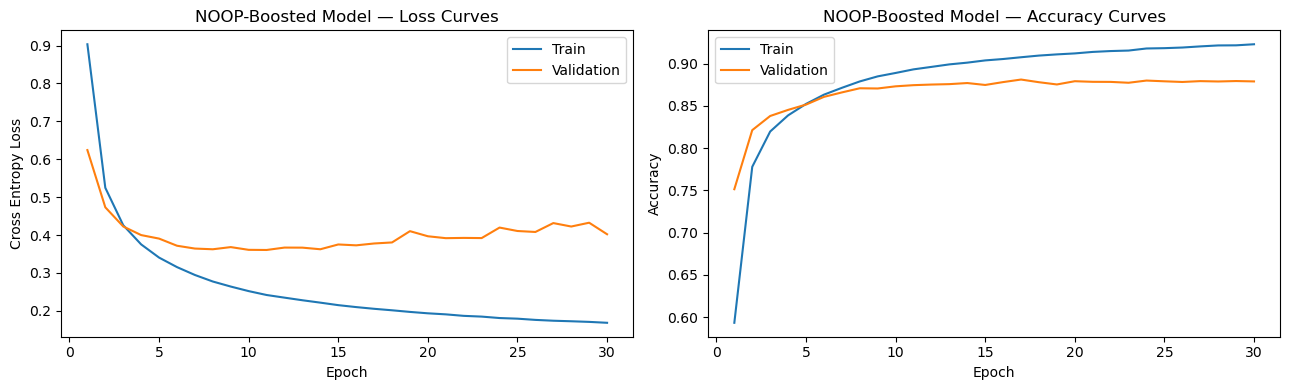

Figure saved to outputs/figures/noop_boosted_learning_curves.png


In [42]:
import time

print(f'Training NOOP-boosted model for {EPOCHS} epochs on {DEVICE}...')
print()

noop_history  = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
epoch_times   = []
train_start   = time.time()

for epoch in range(1, EPOCHS + 1):
    epoch_start = time.time()
    tr_loss, tr_acc = train_one_epoch(noop_model, train_loader_base, noop_optimizer, noop_criterion, DEVICE)
    vl_loss, vl_acc = eval_epoch(noop_model, val_loader_base, noop_criterion, DEVICE)
    epoch_elapsed   = time.time() - epoch_start
    epoch_times.append(epoch_elapsed)
    noop_history['train_loss'].append(tr_loss)
    noop_history['train_acc'].append(tr_acc)
    noop_history['val_loss'].append(vl_loss)
    noop_history['val_acc'].append(vl_acc)
    print(f'Epoch {epoch:>3}/{EPOCHS}  '
          f'train loss={tr_loss:.4f}  acc={tr_acc:.4f}  |  '
          f'val loss={vl_loss:.4f}  acc={vl_acc:.4f}  |  '
          f'{epoch_elapsed:.1f}s')

noop_train_time = time.time() - train_start
save_checkpoint(noop_model, ARTIFACTS_DIR / 'noop_boosted_model.pt')
print()
print(f'Total training time : {noop_train_time:.1f}s ({noop_train_time/60:.1f} min)')
print(f'Avg time per epoch  : {sum(epoch_times)/len(epoch_times):.1f}s')
print('NOOP-boosted model checkpoint saved.')

# Learning curves
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
epochs_x = range(1, EPOCHS + 1)

axes[0].plot(epochs_x, noop_history['train_loss'], label='Train')
axes[0].plot(epochs_x, noop_history['val_loss'],   label='Validation')
axes[0].set_title('NOOP-Boosted Model — Loss Curves')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross Entropy Loss')
axes[0].legend()

axes[1].plot(epochs_x, noop_history['train_acc'], label='Train')
axes[1].plot(epochs_x, noop_history['val_acc'],   label='Validation')
axes[1].set_title('NOOP-Boosted Model — Accuracy Curves')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

fig.tight_layout()
fig.savefig(FIGURES_DIR / 'noop_boosted_learning_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print('Figure saved to outputs/figures/noop_boosted_learning_curves.png')

In [43]:
# Evaluate NOOP-boosted model on test set
print('Evaluating NOOP-boosted model on test set...')
noop_results = evaluate_model(noop_model, test_loader_base, DEVICE, ACTION_NAMES)

# Three-model comparison
print()
print('=== Three-Model Test Set Comparison ===')
print(f'{"Metric":<20} {"Baseline":>12} {"NOOP-Boosted":>14} {"Stacked (4fr)":>15}')
print('-' * 64)
for label, bv, nv, sv in [
    ('Accuracy', baseline_results['accuracy'], noop_results['accuracy'], stacked_results['accuracy']),
    ('Macro F1', baseline_results['f1_macro'],  noop_results['f1_macro'],  stacked_results['f1_macro']),
]:
    print(f'{label:<20} {bv:>12.4f} {nv:>14.4f} {sv:>15.4f}')

print()
print('--- Per-class F1 comparison ---')
print(f'{"Class":<8} {"Baseline F1":>13} {"NOOP-Boosted F1":>17} {"Stacked F1":>12}')
print('-' * 54)
for i, name in enumerate(ACTION_NAMES):
    bf = baseline_results['f1_per_class'][i]
    nf = noop_results['f1_per_class'][i]
    sf = stacked_results['f1_per_class'][i]
    print(f'{name:<8} {bf:>13.4f} {nf:>17.4f} {sf:>12.4f}')

print()
print('--- NOOP class detail ---')
print(f'{"Model":<18} {"Precision":>10} {"Recall":>8} {"F1":>8}')
print('-' * 46)
for model_name, res in [('Baseline', baseline_results), ('NOOP-Boosted', noop_results), ('Stacked', stacked_results)]:
    p = res['precision_per_class'][0]
    r = res['recall_per_class'][0]
    f = res['f1_per_class'][0]
    print(f'{model_name:<18} {p:>10.4f} {r:>8.4f} {f:>8.4f}')

Evaluating NOOP-boosted model on test set...

=== Three-Model Test Set Comparison ===
Metric                   Baseline   NOOP-Boosted   Stacked (4fr)
----------------------------------------------------------------
Accuracy                   0.8733         0.8717          0.9154
Macro F1                   0.8750         0.8745          0.9176

--- Per-class F1 comparison ---
Class      Baseline F1   NOOP-Boosted F1   Stacked F1
------------------------------------------------------
NOOP            0.8818            0.8797       0.9007
RIGHT           0.8599            0.8576       0.9132
LEFT            0.8725            0.8666       0.9251
UP              0.8891            0.8856       0.9224
DOWN            0.8715            0.8832       0.9267

--- NOOP class detail ---
Model               Precision   Recall       F1
----------------------------------------------
Baseline               0.9075   0.8575   0.8818
NOOP-Boosted           0.8597   0.9006   0.8797
Stacked                0

**Experiment 2 results: NOOP-boosted class weight.** Boosting the NOOP class weight by 2x produced exactly the precision-recall tradeoff the experiment was designed to test. NOOP recall improved from 0.857 to 0.901, a gain of 4.3 percentage points. However, NOOP precision fell from 0.908 to 0.860 as the model began over predicting NOOP, misclassifying some directional frames as idle. The net effect on NOOP F1 is negligible (-0.2pp), and overall accuracy and macro F1 are essentially unchanged from the baseline. Boosting the class weight moved the model along the precision-recall tradeoff curve for NOOP but did not escape it.

This result empirically confirms that flat multi class classification creates a structural tension between NOOP and directional classes that cannot be resolved through weight adjustment alone. The weight knob redistributes error between precision and recall without reducing total NOOP misclassifications. Notably, the 4 frame stacked model achieves better NOOP recall than the balanced baseline (0.871 vs 0.857) without sacrificing precision, because temporal context provides a genuine signal.   Four consecutive frames can distinguish a player who is idle from one who is in motion, whereas a static frame cannot.

This points to a hierarchical cascade architecture as a potential solution: a Stage 1 binary classifier trained on the idle vs active distinction alone, feeding into a Stage 2 directional classifier. Each stage would face a simpler and better defined decision boundary, eliminating the gradient tension that limits flat classification performance on NOOP in this task.

## 10. Error Analysis and Failure Cases

In [48]:
# Error analysis on the best model (4-frame stacked) — test set
stacked_model.eval()
all_preds, all_true, all_indices = [], [], []
offset = 0
with torch.no_grad():
    for frames_batch, labels_batch in test_loader_stack:
        preds = stacked_model(frames_batch.to(DEVICE)).argmax(1).cpu().numpy()
        for i, (p, t) in enumerate(zip(preds, labels_batch.numpy())):
            all_preds.append(p)
            all_true.append(t)
            all_indices.append(offset + i)
        offset += len(labels_batch)

all_preds   = np.array(all_preds)
all_true    = np.array(all_true)
all_indices = np.array(all_indices)

errors_mask = all_preds != all_true
error_preds = all_preds[errors_mask]
error_true  = all_true[errors_mask]
error_idx   = all_indices[errors_mask]

print(f'Total test frames   : {len(all_true):,}')
print(f'Misclassified frames: {errors_mask.sum():,}  ({errors_mask.mean()*100:.1f}%)')
print()

# Most common confusion pairs
pair_counts = Counter(zip(error_true.tolist(), error_preds.tolist()))
print('Top 10 confusion pairs (true → predicted):')
print(f'  {"True":<8} {"Predicted":<10} {"Count":>7}')
print('-' * 30)
for (t, p), cnt in pair_counts.most_common(10):
    print(f'  {ACTION_NAMES[t]:<8} → {ACTION_NAMES[p]:<10} {cnt:>7,}')

Total test frames   : 66,739
Misclassified frames: 5,649  (8.5%)

Top 10 confusion pairs (true → predicted):
  True     Predicted    Count
------------------------------
  NOOP     → RIGHT          976
  NOOP     → LEFT           858
  LEFT     → NOOP           497
  RIGHT    → NOOP           482
  LEFT     → RIGHT          471
  RIGHT    → LEFT           416
  NOOP     → DOWN           360
  NOOP     → UP             222
  RIGHT    → UP             219
  LEFT     → UP             215


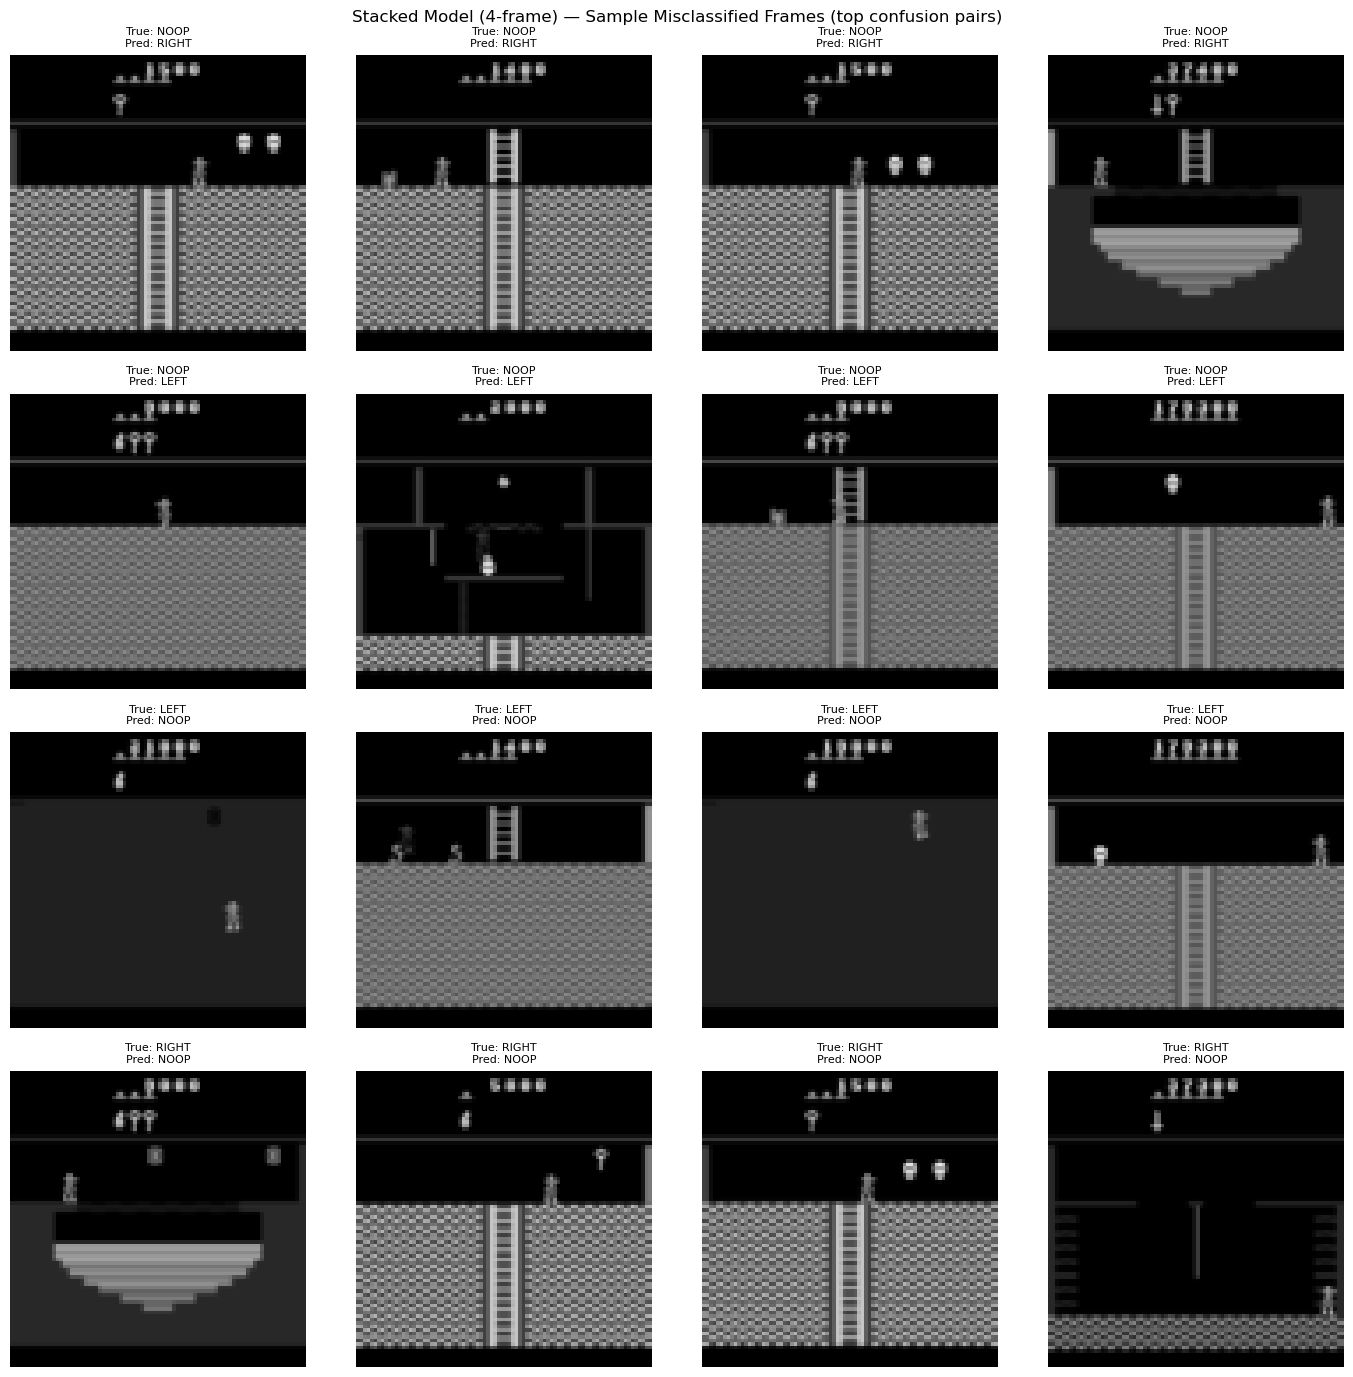

Figure saved to outputs/figures/error_analysis_samples.png


In [49]:
# Visual grid — sample misclassified frames from top 4 confusion pairs
# Each sample index maps into the stacked dataset; we show the last frame
# of the 4-frame stack (the frame being predicted at that timestep).
top_pairs = [pair for pair, _ in pair_counts.most_common(4)]

fig, axes = plt.subplots(len(top_pairs), 4, figsize=(14, 3.5 * len(top_pairs)))

for row, (true_cls, pred_cls) in enumerate(top_pairs):
    pair_mask = (error_true == true_cls) & (error_preds == pred_cls)
    pair_idx  = error_idx[pair_mask]
    chosen    = np.random.default_rng(SEED).choice(pair_idx, size=min(4, len(pair_idx)), replace=False)
    for col in range(4):
        ax = axes[row, col]
        if col < len(chosen):
            # valid_indices[i] gives the start of the 4-frame stack in test_frames;
            # add STACK_SIZE-1 to get the labeled (last) frame of that stack
            frame_pos = int(test_ds_stack.valid_indices[chosen[col]]) + STACK_SIZE - 1
            ax.imshow(test_frames[frame_pos], cmap='gray', vmin=0, vmax=255)
            ax.set_title(f'True: {ACTION_NAMES[true_cls]}\nPred: {ACTION_NAMES[pred_cls]}', fontsize=8)
        ax.axis('off')

fig.suptitle('Stacked Model (4-frame) — Sample Misclassified Frames (top confusion pairs)', fontsize=12)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'error_analysis_samples.png', dpi=120, bbox_inches='tight')
plt.show()
print('Figure saved to outputs/figures/error_analysis_samples.png')

**Error analysis findings.** The stacked model misclassifies 8.5% of test frames (approximately 5,670 of 66,739), a meaningful reduction from the baseline's 12.7% error rate. The confusion patterns are highly structured and reveal what genuinely hard cases remain after temporal context is accounted for.

NOOP is the single largest source of errors: NOOP predicted as LEFT and NOOP predicted as RIGHT are the top two confusion pairs, together accounting for roughly 32.5% of all errors. This is the expected pattern given the three model comparison: an idle player standing in a neutral pose near a platform edge produces frames that are visually similar to the early frames of a horizontal movement, and even four consecutive frames of a stationary player can look like the startup phase of a rightward or leftward move.

RIGHT-LEFT confusion, the dominant error mode in the baseline, is substantially reduced in the stacked model. Four consecutive frames encode direction of travel directly, which resolves most of the ambiguity that a static snapshot cannot. Cases that remain are likely mid reversal frames where the player stops one direction and begins another within the four frame window.

UP and DOWN errors are rare and do not appear among the top confusion pairs, consistent with their strong recall scores (0.95 and 0.96). Ladder and rope traversal involves distinctive postures and positions that are visually separable even at 84x84 resolution, and four frame stacking reinforces the vertical trajectory signal further.

The remaining errors in the stacked model are structurally concentrated in the NOOP vs. action boundary, not the directional distinctions. This confirms that the hierarchical cascade architecture remains a potential next step: separating the idle detection problem from the directional prediction problem would target precisely the confusion pattern that persists at this accuracy level.

## 11. Limitations, Risks, and Responsible Use

placeholder — written in Section 11

## 12. Future Integrations

placeholder — written in Section 12

## 13. Final Notebook Summary

placeholder — written in Section 13

## References

placeholder — written at end